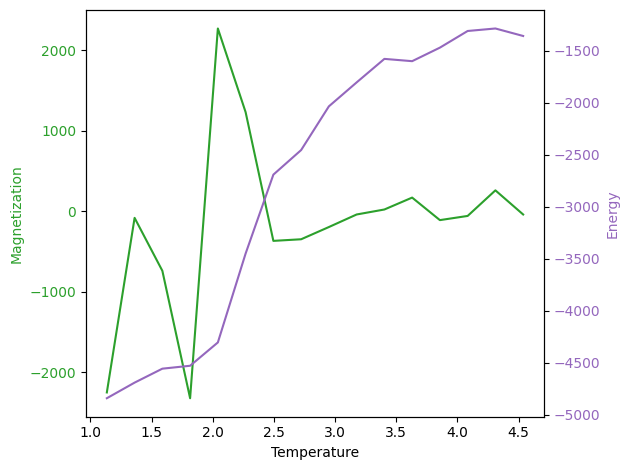

In [2]:
# 50 x 50 Ising Model -- Mag and Energy v Temp
# I essentially changed up the code from slides 126-128 of ch.10 notes
# I have included two funcs: lattice() and  monte_c()

from math import exp
from numpy import empty, sum, arange
from random import random, randrange
from pylab import plot, show, xlabel, ylabel, subplots

# params
L = 50
N = 1000000
J = 1.0
Tc = 2.269 * J


# lattice func.
# lattice points i.e. spin values -- either +1 or -1
# need 50 by 50
def lattice():
    s = empty([L,L], int)
    for i in range(L):
        for j in range(L):
            if random() < 0.5:
                s[i,j] = 1
            else:
                s[i,j] = -1
    return s


# energy func.
# loop through rows and columns of lattice points (spins)
# add spin values and multiply by strength between lattice points, J, rather -J
def energy(s):
    return -J * (sum(s[0:L-1,:]*s[1:L,:]) + sum(s[:,0:L-1]*s[:,1:L]))



# monte_c func.
def monte_c (T):
    s = lattice()
    E = energy(s)
    M = sum(s)

    for k in range(N):

        # save energy before spin flip
        oldE = E

        # choose a random spin
        i = randrange(L)
        j = randrange(L)

        # considering spins above (iup), below (idown),  right (jup), left (jdown)
        # '% L' to stay between [0,L]
        iup = (i+1) % L
        idown = (i-1) % L
        jup = (j+1) % L
        jdown = (j-1) % L

        # change in energy: deltaE
        # (2) comes from (1 - (-1) = 2)
        deltaE = 2 * J * s[i,j]*(s[iup,j]+s[idown,j]+s[i,jup]+s[i,jdown])

        # if deltaE < 0 or random number < Boltzmann const.
        # no transistion to higher energy
        if deltaE < 0 or random() < exp(-deltaE / T):
            s[i,j] *= -1
            E += deltaE

    return sum(s), E


# getting 5 temp values to plot -- k should be between (0.5 - 2)
# setting up lists to use for "pretty" plotting: mag and energy v temp
temps = [Tc * k for k in arange(0.5, 2.1, 0.1)]
mag_vals = []
energy_vals = []


# loop through temps -- send through monte_c func.
# add vals to mag and energy lists to use for plotting
for T in temps:
    M, E = monte_c(T)
    mag_vals.append(M)
    energy_vals.append(E)


# setting up first plot
fig, ax1 = subplots()

# magnetization
color = 'tab:green'
ax1.set_xlabel('Temperature')
ax1.set_ylabel('Magnetization', color=color)
ax1.plot(temps, mag_vals, color=color)
ax1.tick_params(axis='y', labelcolor=color)


# setting up second plot
ax2 = ax1.twinx()

# energy
color = 'tab:purple'
ax2.set_ylabel('Energy', color=color)
ax2.plot(temps, energy_vals, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
show()